In [5]:
import os
import json
import math
import warnings
from typing import Dict, Any

import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss

import os
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve


warnings.filterwarnings("ignore")

# 0) USER CONFIG

In [6]:
WOE_OUTPUT_DIR = "/content"
OUTPUT_DIR = "/content/logreg_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

PLOT_DIR = "/content/thesis_plots"
os.makedirs(PLOT_DIR, exist_ok=True)


TARGET = "Default"
SEED = 42

# Conservative uplift for proxy-LRADR approximation
CONSERVATISM_UPLIFT = 0.30

# Optional illustrative PD floor
APPLY_PD_FLOOR = True
PD_FLOOR = 0.0005

# Bootstrap sizes. higher for more stable MoC_C. lower if runtime too high
N_BOOT_TEST = 60
N_BOOT_TRAIN = 40

# Logistic-regression model-selection grid
GRID = [
    {"C": 0.5},
    {"C": 1.0},
    {"C": 1.5},
    {"C": 0.01},
    {"C": 0.05},
    {"C": 0.1},
    {"C": 0.25},
    {"C": 2.0},
    {"C": 5.0},
    {"C": 10.0}
]

# Conservative alternative specifications for MoC_A
# Approximated via sensitivity to alternative regularization specifications.
# MoC_A = Uncertainty due to methodological decisions
# MoC_A(i) = max( PD_conservative(i) − PD_BE(i), 0 ) --> take difference only if it is pos
ADVERSE_SPECS = [
    {"C": 0.25},
    {"C": 0.5},
    {"C": 2.0},
]


# 1) HELPER FUNCTIONS

In [7]:
# Reads a CSV file and raises an error if the file does not exist
def read_required_csv(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Required file not found: {path}")
    return pd.read_csv(path)

# Splits the dataframe into features (X) and target (y) and validates that the target is binary (0/1)
def split_xy(data, target):
    if target not in data:
        raise ValueError(f"Target column '{target}' not found")

    y = data[target].astype(int)

    if not set(y.unique()).issubset({0, 1}):
        raise ValueError("Target must be binary 0/1")

    return data.drop(columns=target), y


# Convert probabilities to log-odds
def logit(p):
    p = np.clip(np.asarray(p, dtype=float), 1e-12, 1 - 1e-12) # clip to  Avoid p = 0 or p = 1 --> no infinite values in logit transformation
    return np.log(p / (1 - p))

# Convert log-odds to probabilities using the sigmoid function
def inv_logit(z):
    return 1 / (1 + np.exp(-np.asarray(z, dtype=float)))

# Compute KS statistic for rank-ordering performance
# Defaults are concentrated among high PD values → indicates good risk discrimination
def ks_statistic(y_true, pd_pred):
    tmp = pd.DataFrame({
        "y": np.asarray(y_true).astype(int),
        "pd": np.asarray(pd_pred)
    }).sort_values("pd", ascending=False)  # risky to not risky

    #sum at least 1
    total_bad = max((tmp["y"] == 1).sum(), 1)
    total_good = max((tmp["y"] == 0).sum(), 1)

    # Normalization  ∈ [0, 1]
    cum_bad = (tmp["y"] == 1).cumsum() / total_bad
    cum_good = (tmp["y"] == 0).cumsum() / total_good

    return float(np.max(np.abs(cum_bad - cum_good))) # highest difference


# Create bucket-level calibration table
# calibration_gap ≈ 0 --> good calibration, calibration_gap > 0 --> model over estimate risk, calibration_gap < 0 --> model underestimate risk (risky in banking)
def calibration_table(y_true, pd_pred, n_buckets=10):
    tmp = pd.DataFrame({
        "y": np.asarray(y_true).astype(int),
        "pd": np.asarray(pd_pred)
    })

    tmp["bucket"] = pd.qcut(tmp["pd"], q=n_buckets, duplicates="drop") # all buckets almost same count of customers

    out = tmp.groupby("bucket", observed=False).agg(
        obs=("y", "count"),
        defaults=("y", "sum"),  # count of defaults
        avg_pd=("pd", "mean"),
        pd_min=("pd", "min"),
        pd_max=("pd", "max"),
    ).reset_index()

    out["observed_dr"] = out["defaults"] / out["obs"]  # default rate
    out["calibration_gap"] = out["avg_pd"] - out["observed_dr"]

    return out

# Not a formal audit replacement, but a useful grouped calibration signal. a grouped calibration statistic inspired by the Hosmer-Lemeshow approach
# This is only used as a diagnostic signal, not as a formal statistical test.
def hosmer_lemeshow_like(y_true, pd_pred, n_buckets=10):
    tab = calibration_table(y_true, pd_pred, n_buckets)
    eps = 1e-8
    # clip with eps so it can't get below 0 --> important for devision
    expected_bad = np.clip(tab["avg_pd"] * tab["obs"], eps, None)
    expected_good = np.clip((1 - tab["avg_pd"]) * tab["obs"], eps, None)
    # observed
    observed_bad = tab["defaults"]
    observed_good = tab["obs"] - tab["defaults"]

    hl = ((observed_bad - expected_bad) ** 2 / expected_bad).sum()
    hl += ((observed_good - expected_good) ** 2 / expected_good).sum()
    # if observed_bad ≈ expected_bad --> good calibration
    return float(hl)

# Evaluates how well the model separates good vs. bad customers (discrimination) and how accurate are the predicted probabilities (calibration)
def evaluate_pd(y_true, pd_pred, prefix):
    auc = roc_auc_score(y_true, pd_pred)

    return {
        f"{prefix}_auc": float(auc),
        f"{prefix}_gini": float(2 * auc - 1),  # AUC-Gini
        f"{prefix}_ks": ks_statistic(y_true, pd_pred),
        f"{prefix}_brier": float(brier_score_loss(y_true, pd_pred)),
        f"{prefix}_logloss": float(log_loss(y_true, pd_pred)),
        f"{prefix}_hl_like": hosmer_lemeshow_like(y_true, pd_pred),
        f"{prefix}_mean_pd": float(np.mean(pd_pred)),
        f"{prefix}_obs_dr": float(np.mean(y_true)),
    }


# Compute PSI between two score distributions
def population_stability_index(reference, current, buckets=10):
    reference = pd.Series(reference).astype(float)
    current = pd.Series(current).astype(float)

    cuts = np.unique(np.quantile(reference, np.linspace(0, 1, buckets + 1)))

    if len(cuts) < 3:  # if almost no sensful buckets are possible, psi is not meaningful
        return 0.0
    # open borders
    cuts[0] = -np.inf
    cuts[-1] = np.inf

    reference_bins = pd.cut(reference, bins=cuts, include_lowest=True)
    current_bins = pd.cut(current, bins=cuts, include_lowest=True)

    # normalize=True --> relative frequencies instead of counts for distribution
    reference_dist = reference_bins.value_counts(normalize=True, sort=False)
    current_dist = current_bins.value_counts(normalize=True, sort=False)

    psi = 0.0

    for bucket in reference_dist.index:
        pe = max(float(reference_dist.get(bucket, 0)), 1e-8)
        pa = max(float(current_dist.get(bucket, 0)), 1e-8)
        psi += (pa - pe) * math.log(pa / pe)  # formula

    return float(psi)


# It calibrates the average default risk of the portfolio
# By shifting the PDs towards the target LRADR (target_lradr), the overall risk level is adjusted so that it is not systematically under- or overestimated
# global logit shift α is reached for -->  shifts all PDs together so that the average PD is as close as possible to the target rate (here LRADR)
def calibrate_to_target_mean(pd_values, target_mean, tol=1e-12):
    if not (0 < target_mean < 1):
        raise ValueError("target_mean must be between 0 and 1")

    base_logit = logit(pd_values)
    # range for alpha
    lower = -20.0
    upper = 20.0

    for _ in range(250):
        alpha = (lower + upper) / 2
        calibrated_pd = inv_logit(base_logit + alpha)

        if abs(calibrated_pd.mean() - target_mean) < tol:
            return calibrated_pd, alpha

        if calibrated_pd.mean() < target_mean:
            lower = alpha
        else:
            upper = alpha

    alpha = (lower + upper) / 2 # fallback solution
    return inv_logit(base_logit + alpha), alpha

# Estimate MoC_C from bootstrap-based variability of calibrated PD predictions
# The WoE transformation remains fixed --> only the model is re-estimated
# Sampling with replacement
def bootstrap_moc_c_logreg(
    X_train,
    y_train,
    X_eval,
    C,
    calibration_alpha,
    n_boot=50,  # bootstrap models
    alpha_q=0.95, # rather high plausible PD
    random_state=42,
):

    rng = np.random.RandomState(random_state) # random numbers
    all_pd_predictions = []

    # Clean indexing as important for .iloc
    X_train = X_train.reset_index(drop=True)
    y_train = y_train.reset_index(drop=True)
    X_eval = X_eval.reset_index(drop=True)

    for _ in range(n_boot):

        # Bootstrap sample indices
        sample_idx = rng.randint(0, len(X_train), len(X_train))

        # Bootstrap sample
        X_boot = X_train.iloc[sample_idx]
        y_boot = y_train.iloc[sample_idx]

        # Train bootstrap model
        model = LogisticRegression(
            penalty="l2",
            C=C,
            solver="lbfgs",
            max_iter=5000,
            random_state=SEED,
        )

        model.fit(X_boot, y_boot)

        # Raw PD predictions
        pd_raw = model.predict_proba(X_eval)[:, 1]

        # Best-estimate calibrated PDs
        pd_calibrated = inv_logit(logit(pd_raw) + calibration_alpha)

        all_pd_predictions.append(pd_calibrated)

    # Shape: [n_bootstrap_models, n_observations]
    pred_matrix = np.vstack(all_pd_predictions)

    # Mean PD across bootstrap models
    pd_mean = pred_matrix.mean(axis=0) # Column wise: Average PD per customer across all Bootstrap models

    # Conservative quantile PD calculation (95%q)
    pd_quantile = np.quantile(pred_matrix, alpha_q, axis=0)

    # MoC_C uplift
    moc_c = np.maximum(pd_quantile - pd_mean, 0.0)  # only positive surcharge

    return pd_mean, moc_c, pred_matrix

# Use a set of conservative alternative specifications
# MoC_A = Uncertainty due to methodological decisions
# MoC_A(i) = max( PD_conservative(i) − PD_BE(i), 0 ) --> take difference only if it is pos
# adverse means in credit risk less favorable / more conservative situation
def compute_adverse_moc_a(
    X_train,
    y_train,
    X_eval,
    y_eval,
    baseline_pd_be,
    alpha_shift,
    adverse_specs,
    prefix,
):
    adverse_pd_list = []
    adverse_rows = []

    for spec in adverse_specs:
        _, _, adverse_pd_raw = fit_logreg_model(
            X_train=X_train,
            y_train=y_train,
            X_eval=X_eval,
            C=spec["C"],
        )

        adverse_pd_be = inv_logit(logit(adverse_pd_raw) + alpha_shift)  # all adverse model use same BE-calibration
        adverse_pd_list.append(adverse_pd_be)

        row = spec.copy()
        row.update(evaluate_pd(y_eval, adverse_pd_be, prefix))
        adverse_rows.append(row)

    adverse_table = pd.DataFrame(adverse_rows)

    if len(adverse_pd_list) == 0:
        moc_a = np.zeros_like(baseline_pd_be)    # if no adverse model , no MoC_A sucharge
        return moc_a, adverse_table

    adverse_matrix = np.vstack(adverse_pd_list)
    adverse_conservative = np.quantile(adverse_matrix, 0.75, axis=0)

    moc_a = np.maximum(adverse_conservative - baseline_pd_be, 0.0)

    return moc_a, adverse_table

# Descriptive coefficient review only; not a formal validation criterion --> for interpretability
def coefficient_sign_review(coef_df):
    out = coef_df.copy()
    out["sign"] = np.where(out["coefficient"] < 0, "negative", "positive_or_zero")
    return out

# Final conservative PDs --> Best-Estimate PD + MoC_A + MoC_C + mandatory PD floor
def apply_final_pd_adjustments(pd_be, moc_a, moc_c, pd_floor=0.0005):

    # Combine BE PD with conservatism adjustments
    pd_final = pd_be + moc_a + moc_c

    # PDs must remain between 0 and 1
    pd_final = np.clip(pd_final, 0, 1)

    # Apply mandatory minimum PD floor
    pd_final = np.maximum(pd_final, pd_floor)

    return pd_final


# 2) LOAD PRECOMPUTED WOE DATASETS

In [8]:
train_woe = read_required_csv(os.path.join(WOE_OUTPUT_DIR, "train_woe.csv"))
val_woe = read_required_csv(os.path.join(WOE_OUTPUT_DIR, "val_woe.csv"))
test_woe = read_required_csv(os.path.join(WOE_OUTPUT_DIR, "test_woe.csv"))

train_final_woe = read_required_csv(os.path.join(WOE_OUTPUT_DIR, "train_final_woe.csv"))
test_final_woe = read_required_csv(os.path.join(WOE_OUTPUT_DIR, "test_final_woe.csv"))

X_train, y_train = split_xy(train_woe, TARGET)
X_val, y_val = split_xy(val_woe, TARGET)
X_test_dev, y_test_dev = split_xy(test_woe, TARGET)

X_train_final, y_train_final = split_xy(train_final_woe, TARGET)
X_test_final, y_test_final = split_xy(test_final_woe, TARGET)

# Make sure final train and final test use the same WoE feature columns
if list(X_train_final.columns) != list(X_test_final.columns):
    raise ValueError("Feature columns in train_final_woe and test_final_woe do not match")

# Make sure model-selection train, val, and test use the same WoE feature columns
if list(X_train.columns) != list(X_val.columns):
    raise ValueError("Feature columns in train_woe and val_woe do not match")
if list(X_train.columns) != list(X_test_dev.columns):
    raise ValueError("Feature columns in train_woe and test_woe do not match")

# Make sure both test files refer to the same target vector
if not np.array_equal(y_test_dev.values, y_test_final.values):
    raise ValueError("test_woe and test_final_woe do not contain the same target values")


# 3) LOAD FINAL WOE DOCUMENTATION TABLES

In [9]:
# For the final scorecard, the WoE table must correspond to the final WoE transformer fitted on train + validation --> see WoE-Skript
woe_table_final_path = os.path.join(WOE_OUTPUT_DIR, "woe_table_all_final.csv")
iv_summary_final_path = os.path.join(WOE_OUTPUT_DIR, "iv_summary_final.csv")
metadata_final_path = os.path.join(WOE_OUTPUT_DIR, "woe_metadata_final.json")

if os.path.exists(woe_table_final_path):
    woe_table_all_final = pd.read_csv(woe_table_final_path)
else:
    raise FileNotFoundError(
        "woe_table_all_final.csv is required for the final scorecard. "
        "Please save it from the WoE preprocessing script using the final WoE transformer."  # not optional
    )

if os.path.exists(iv_summary_final_path):
    iv_summary_final = pd.read_csv(iv_summary_final_path)
else:
    iv_summary_final = None  # optional

if os.path.exists(metadata_final_path):
    with open(metadata_final_path, "r", encoding="utf-8") as f:
        woe_metadata_final = json.load(f)
else:
    woe_metadata_final = {}  # optional


# Loads a CSV file and raises a clear error if it is missing
def read_required_csv(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Required file not found: {path}")
    return pd.read_csv(path)


# Splits dataframe into X and y
def split_xy(data, target):
    if target not in data.columns:
        raise ValueError(f"Target column '{target}' not found")

    X = data.drop(columns=[target]).copy()
    y = data[target].astype(int).copy()

    if not set(np.unique(y)).issubset({0, 1}):
        raise ValueError("Target must be binary 0/1")

    return X, y


# 4) MODEL SELECTION ON TRAIN / VALIDATION WOE DATA


In [10]:
def fit_logreg_model(X_train, y_train, X_eval, C=1.0):
    # Fit logistic regression and return raw PD predictions
    model = LogisticRegression(
        # L2 reg penalizes extreme weights, forcing a stable distribution across many small weights for smoother, more reliable curves
        penalty="l2",
        C=C,
        solver="lbfgs", # Limited-memory Broyden-Fletcher-Goldfarb-Shanno, good for L2
        max_iter=3000,
        class_weight=None,
        random_state=SEED
    )

    model.fit(X_train, y_train)

    train_pred = model.predict_proba(X_train)[:, 1]  # proba for defaults
    eval_pred = model.predict_proba(X_eval)[:, 1]  # validation data

    return model, train_pred, eval_pred


def choose_logreg_by_validation(X_train, y_train, X_val, y_val, grid):
    # Select best C based on validation performance
    results = []
    best_model = None
    best_params = None
    best_metrics = None
    best_score = -np.inf

    for params in grid:
        model, _, val_pred = fit_logreg_model(
            X_train,
            y_train,
            X_val,
            C=params["C"]
        )

        metrics = evaluate_pd(y_val, val_pred, "val")

        calibration_gap = abs(metrics["val_mean_pd"] - metrics["val_obs_dr"])
        accepted = calibration_gap <= 0.02    # pragmatic threshold:  max. 2 percentage points

        row = params.copy()
        row.update(metrics)
        row["val_calibration_gap"] = calibration_gap
        row["accepted"] = accepted
        results.append(row)  # metrics are stored

        # models with too large global calibration gap are excluded
        if not accepted:
            continue
       # Among accepted models,  the one with the highest validation Gini is selected
        score = metrics["val_gini"]

        if score > best_score:  # model update
            best_score = score
            best_model = model
            best_params = params
            best_metrics = metrics

    results = pd.DataFrame(results).sort_values(
      ["accepted", "val_gini", "val_ks"],
      ascending=False
    ).reset_index(drop=True)

    return (best_model, best_params, best_metrics), results


# Perform validation-based model selection across multiple logistic regression configurations using different regularization strengths (C values)
(best_bundle, model_selection_table) = choose_logreg_by_validation(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    grid=GRID,
)
# Extract the regularization parameter of the selected validation model
_, best_params, val_metrics = best_bundle # best_model is not needed --> train final one later

if best_params is None:
    raise ValueError(
        "No logistic regression model satisfied the validation selection constraints.")

best_C = best_params["C"]

# 5) FINAL LOGISTIC REGRESSION ON TRAIN + VALIDATION WOE DATA

In [11]:
logreg_model, pd_train_raw, pd_test_raw = fit_logreg_model(
    X_train=X_train_final,
    y_train=y_train_final,
    X_eval=X_test_final,
    C=best_C,
)

# final evaluation
raw_train_metrics = evaluate_pd(y_train_final, pd_train_raw, "train_raw")
raw_test_metrics = evaluate_pd(y_test_final, pd_test_raw, "test_raw")


# 6) BEST-ESTIMATE (BE): CALIBRATION

In [12]:
observed_train_dr = float(y_train_final.mean())  # Observed average default rate in final training
proxy_lradr = observed_train_dr * (1 + CONSERVATISM_UPLIFT)
target_lradr = proxy_lradr

pd_train_be, alpha_shift = calibrate_to_target_mean(pd_train_raw, target_lradr) # shift to proxy LRADR
pd_test_be = inv_logit(logit(pd_test_raw) + alpha_shift) # same calibration on test data

be_train_metrics = evaluate_pd(y_train_final, pd_train_be, "train_be")
be_test_metrics = evaluate_pd(y_test_final, pd_test_be, "test_be")


# 7) MoC_A: METHOD SENSITIVITY

In [13]:
moc_a_test, adverse_specs_table = compute_adverse_moc_a(
    X_train=X_train_final,
    y_train=y_train_final,
    X_eval=X_test_final,
    y_eval=y_test_final,
    baseline_pd_be=pd_test_be,
    alpha_shift=alpha_shift,
    adverse_specs=ADVERSE_SPECS,
    prefix="adv_be",
)

moc_a_train, train_adverse_specs_table = compute_adverse_moc_a(
    X_train=X_train_final,
    y_train=y_train_final,
    X_eval=X_train_final,
    y_eval=y_train_final,
    baseline_pd_be=pd_train_be,
    alpha_shift=alpha_shift,
    adverse_specs=ADVERSE_SPECS,
    prefix="train_adv_be",
)

# 8) MoC_C: BOOTSTRAP ESTIMATION UNCERTAINTY

In [14]:
pd_test_boot_mean, moc_c_test, pred_matrix_test = bootstrap_moc_c_logreg(
    X_train=X_train_final,
    y_train=y_train_final,
    X_eval=X_test_final,
    C=best_C,
    calibration_alpha=alpha_shift,
    n_boot=N_BOOT_TEST,
    alpha_q=0.95,
    random_state=SEED,
)

pd_train_boot_mean, moc_c_train, pred_matrix_train = bootstrap_moc_c_logreg(
    X_train=X_train_final,
    y_train=y_train_final,
    X_eval=X_train_final,
    C=best_C,
    calibration_alpha=alpha_shift,
    n_boot=N_BOOT_TRAIN,
    alpha_q=0.95,
    random_state=SEED + 1,
)

# 9) FINAL PD CONSTRUCTION

In [15]:
# PDs before appling floor
pd_train_final_pre_floor = np.clip(pd_train_be + moc_a_train + moc_c_train, 0, 1)
pd_test_final_pre_floor = np.clip(pd_test_be + moc_a_test + moc_c_test, 0, 1)

# PDs with floor
pd_train_final = apply_final_pd_adjustments(
    pd_be=pd_train_be,
    moc_a=moc_a_train,
    moc_c=moc_c_train,
    pd_floor=PD_FLOOR,
)

pd_test_final = apply_final_pd_adjustments(
    pd_be=pd_test_be,
    moc_a=moc_a_test,
    moc_c=moc_c_test,
    pd_floor=PD_FLOOR,
)

# final metrics
final_train_metrics = evaluate_pd(y_train_final, pd_train_final, "train_final")
final_test_metrics = evaluate_pd(y_test_final, pd_test_final, "test_final")

# 10) SCORECARD TABLE AND MODEL DIAGNOSTICS

In [16]:
def build_scorecard_outputs(model, X_features, woe_table, alpha_shift):
    # Table of coefficients
    coef_df = (
        pd.DataFrame({
            "feature": X_features.columns,
            "coefficient": model.coef_[0],       # LR coefficients
        })
        .sort_values("coefficient", ascending=False)
        .reset_index(drop=True)
    )

    # Intercept/calibration table
    intercept_df = pd.DataFrame({
        "parameter": ["intercept", "alpha_shift"],
        "value": [float(model.intercept_[0]), float(alpha_shift)],
    })

    # Sign overview
    sign_review_df = coefficient_sign_review(coef_df)

    # Are all model features also present in the WoE table
    missing_features = set(coef_df["feature"]) - set(woe_table["feature"])
    if missing_features:
        raise ValueError(f"Features missing in final WoE table: {sorted(missing_features)}")

    # Final scorecard with logit contributions
    scorecard_df = (
        woe_table[woe_table["feature"].isin(X_features.columns)] # only features that were actually used in the final model
        .merge(coef_df, on="feature", how="left")
        .copy()
    )

    scorecard_df["logit_contribution"] = (
        scorecard_df["woe"] * scorecard_df["coefficient"]  # a bin's contribution to the overall log
    )

    return coef_df, intercept_df, sign_review_df, scorecard_df




coef_df, intercept_df, sign_review_df, scorecard_df = build_scorecard_outputs(
    model=logreg_model,
    X_features=X_train_final,
    woe_table=woe_table_all_final,
    alpha_shift=alpha_shift,
)



# 11) REPORTING TABLES

In [17]:
# Create detailed observation-level test result table
pd_results_test = X_test_final.copy()
pd_results_test["Default_Observed"] = np.asarray(y_test_final)
pd_results_test["PD_raw"] = pd_test_raw
pd_results_test["PD_BE"] = pd_test_be
pd_results_test["MoC_A"] = moc_a_test
pd_results_test["MoC_C"] = moc_c_test
pd_results_test["PD_final_pre_floor"] = pd_test_final_pre_floor
pd_results_test["PD_final"] = pd_test_final


# Bucket analysis: group observations by final PD to assess rank ordering and local calibration across different risk ranges
pd_results_test["pd_bucket"] = pd.qcut(pd_results_test["PD_final"], q=10, duplicates="drop")

rank_ordering = pd_results_test.groupby("pd_bucket", observed=False).agg(
    obs=("Default_Observed", "count"),
    defaults=("Default_Observed", "sum"),
    avg_pd_raw=("PD_raw", "mean"),
    avg_pd_be=("PD_BE", "mean"),
    avg_moc_a=("MoC_A", "mean"),
    avg_moc_c=("MoC_C", "mean"),
    avg_pd_final=("PD_final", "mean"),
).reset_index()

rank_ordering["observed_dr"] = rank_ordering["defaults"] / rank_ordering["obs"] # observed default rate per PD bucket
rank_ordering["gap_final"] = rank_ordering["avg_pd_final"] - rank_ordering["observed_dr"] # average final predicted PD minus observed default rate per bucket, shows if the average final PD in the bucket is above or below the observed default rate; local calibration over risk-classes




# Calibration Tables
cal_table_raw = calibration_table(y_test_final, pd_test_raw, n_buckets=10)   # raw model PDs
cal_table_be = calibration_table(y_test_final, pd_test_be, n_buckets=10)     # best-estimate PDs
cal_table_final = calibration_table(y_test_final, pd_test_final, n_buckets=10) # final PDs including MoCs and floor

# Sample-based stability diagnostic: compare raw PD distributions between final train and test samples
pd_train_model_selection = pd_train_raw
pd_test_model_selection = pd_test_raw

stability_summary = pd.DataFrame({
    "comparison": ["train_final_vs_test_final_raw_pd"],
    "psi": [population_stability_index(pd.Series(pd_train_model_selection), pd.Series(pd_test_model_selection))],
})

validation_summary = pd.DataFrame(
    [
        {"metric": k, "value": v}
        for d in [raw_train_metrics, raw_test_metrics, be_train_metrics, be_test_metrics, final_train_metrics, final_test_metrics]
        for k, v in d.items()
    ]
)

# Shows how much the final PDs were increased on average by MoC_A and MoC_C
moc_summary = pd.DataFrame({
    "component": [
        "MoC_A_mean_train",
        "MoC_C_mean_train",
        "Total_MoC_mean_train",
        "MoC_A_mean_test",
        "MoC_C_mean_test",
        "Total_MoC_mean_test",
    ],
    "value": [
        float(np.mean(moc_a_train)),
        float(np.mean(moc_c_train)),
        float(np.mean(moc_a_train + moc_c_train)),
        float(np.mean(moc_a_test)),
        float(np.mean(moc_c_test)),
        float(np.mean(moc_a_test + moc_c_test)),
    ],
})

method_summary = pd.DataFrame({
    "item": [
        "input_data",
        "scorecard_model",
        "woe_source_model_selection",
        "woe_source_final_model",
        "model_selection",
        "best_estimate_calibration",
        "moc_a",
        "moc_b",
        "moc_c",
        "pd_floor",
        "oot_backtest_possible",
        "long_run_historical_calibration_possible",
    ],
    "value": [
        "Precomputed WoE-transformed datasets",
        "Logistic Regression on WoE features",
        "train_woe, val_woe, test_woe; WoE fitted on train only",
        "train_final_woe, test_final_woe; WoE fitted on train + validation only, test transformed only",
        f"Validation-based choice over C-grid; best C={best_C}",
        f"Intercept shift to target proxy LRADR={target_lradr:.6f}",
        "Sensitivity-based MoC_A using alternative logistic-regression regularization strengths (C values)",
        "Not calculated; no time, process, policy, or historical portfolio information available",
        "95th percentile bootstrap dispersion over bootstrap mean",
        f"Mandatory PD floor with value {PD_FLOOR}",
        "No",
        "No",
    ],
})

limitations_text = """
This workflow implements a logistic-regression scorecard on precomputed WoE-transformed data.
It is materially closer to traditional credit-risk scorecard modelling than a plain classifier,
but it is not an approved IRB system.

What is feasible here:
- WoE-transformed scorecard structure
- Logistic regression on WoE features
- discrimination metrics such as AUC, Gini, and KS
- grouped calibration checks
- best-estimate calibration scaffold
- MoC_A and MoC_C proxy estimation
- final scorecard table with WoE bins, coefficients, and logit contributions

What remains impossible or only partially defensible with this dataset:
- out-of-time backtesting, because no observation dates are available
- vintage analysis, because no dates are available
- long-run average default rate from historical cycles, because this is a single snapshot
- segment-specific models or calibration, because no formal portfolio segmentation fields are available
- MoC_B based on policy, process, or business changes over time
- regulatory default definition according to Article 178 CRR cannot be verified from this dataset
- only proxy LRADR due to missing time dimension and missing long-term historical default observations
""".strip()

model_package = {
    "target": TARGET,
    "woe_output_dir": WOE_OUTPUT_DIR,
    "output_dir": OUTPUT_DIR,
    "best_params": best_params,
    "observed_train_dr": observed_train_dr,
    "proxy_lradr": proxy_lradr,
    "target_proxy_lradr": target_lradr,
    "conservatism_uplift": CONSERVATISM_UPLIFT,
    "lradr_type": "proxy",
    "pd_floor": PD_FLOOR,
    "n_boot_test": N_BOOT_TEST,
    "n_boot_train": N_BOOT_TRAIN,
    "seed": SEED,
    "n_features_final": int(X_train_final.shape[1]),
    "features_final": list(X_train_final.columns),
    "woe_metadata_final": woe_metadata_final,
}


# 12) SAVE OUTPUTS

In [18]:
model_selection_table.to_csv(os.path.join(OUTPUT_DIR, "model_selection_table.csv"), index=False)
adverse_specs_table.to_csv(os.path.join(OUTPUT_DIR, "adverse_specs_table.csv"), index=False)
coef_df.to_csv(os.path.join(OUTPUT_DIR, "woe_logit_coefficients.csv"), index=False)
intercept_df.to_csv(os.path.join(OUTPUT_DIR, "intercepts.csv"), index=False)
sign_review_df.to_csv(os.path.join(OUTPUT_DIR, "coefficient_sign_review.csv"), index=False)
scorecard_df.to_csv(os.path.join(OUTPUT_DIR, "scorecard_table.csv"), index=False)
pd_results_test.to_csv(os.path.join(OUTPUT_DIR, "pd_results_test.csv"), index=False)
rank_ordering.to_csv(os.path.join(OUTPUT_DIR, "rank_ordering.csv"), index=False)
cal_table_raw.to_csv(os.path.join(OUTPUT_DIR, "calibration_table_raw.csv"), index=False)
cal_table_be.to_csv(os.path.join(OUTPUT_DIR, "calibration_table_be.csv"), index=False)
cal_table_final.to_csv(os.path.join(OUTPUT_DIR, "calibration_table_final.csv"), index=False)
stability_summary.to_csv(os.path.join(OUTPUT_DIR, "stability_summary.csv"), index=False)
validation_summary.to_csv(os.path.join(OUTPUT_DIR, "validation_summary.csv"), index=False)
moc_summary.to_csv(os.path.join(OUTPUT_DIR, "moc_summary.csv"), index=False)
method_summary.to_csv(os.path.join(OUTPUT_DIR, "method_summary.csv"), index=False)

if iv_summary_final is not None:
    iv_summary_final.to_csv(os.path.join(OUTPUT_DIR, "iv_summary_final_used.csv"), index=False)

with open(os.path.join(OUTPUT_DIR, "limitations.txt"), "w", encoding="utf-8") as f:
    f.write(limitations_text)

with open(os.path.join(OUTPUT_DIR, "model_package.json"), "w", encoding="utf-8") as f:
    json.dump(model_package, f, indent=2, default=str)


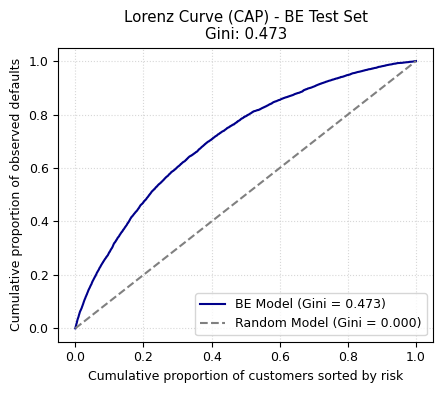

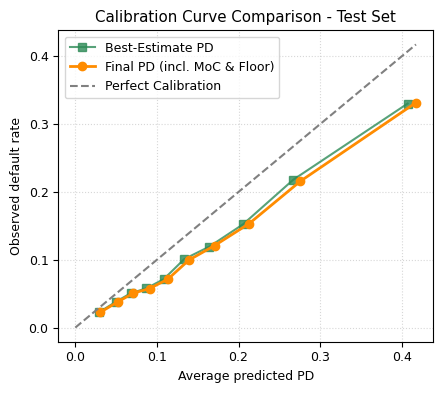

Saved IRBA-compliant plots to: /content/thesis_plots


In [19]:
plt.rcParams.update({
    "font.size": 9
})
# The table pd_results_test contains the observed default indicator,
# the calibrated Best-Estimate PD, and the final regulatory PD.
y_test_true = pd_results_test["Default_Observed"].values
pd_be_test = pd_results_test["PD_BE"].values
pd_final_test = pd_results_test["PD_final"].values

# ------------------------------------------------------------
# Plot 1: Lorenz Curve / CAP Curve - Test Set (IRB Compliant)
# ------------------------------------------------------------
# Purpose:
# Evaluate the discriminatory power of the underlying credit scoring model.
#
# The Lorenz curve shows whether the model ranks borrowers
# correctly from high risk to low risk.
#
# Interpretation:
# - A curve close to the diagonal indicates weak discrimination.
# - A curve clearly above the diagonal indicates good risk separation.
# - The Gini coefficient summarizes the discriminatory power.
#
# IRB Compliance Note:
# Discrimination metrics (Gini/AUC) must be calculated on the unbiased
# Best-Estimate (BE) PDs. Using final PDs with regulatory floors/MoCs
# introduces artificial ties, deflating the true ranking capability.

# Create DataFrame to sort customers by unbiased Best-Estimate risk
df_lorenz = pd.DataFrame({"y_true": y_test_true, "pd_be": pd_be_test})
# Sort borrowers from highest Best-Estimate PD to lowest Best-Estimate PD
df_lorenz = df_lorenz.sort_values(by="pd_be", ascending=False).reset_index(drop=True)

# X-axis: cumulative share of borrowers
cum_population = np.arange(1, len(df_lorenz) + 1) / len(df_lorenz)
# Y-axis: cumulative share of observed defaults captured
cum_defaults = df_lorenz["y_true"].cumsum() / df_lorenz["y_true"].sum()

# ROC-AUC is converted into the Gini coefficient based on BE PDs
roc_auc = roc_auc_score(y_test_true, pd_be_test)
gini_score = 2 * roc_auc - 1

plt.figure(figsize=(4.5, 4))
# Updated label to reflect the Best-Estimate rating model power
plt.plot(cum_population, cum_defaults, color="darkblue", label=f"BE Model (Gini = {gini_score:.3f})")
# Diagonal reference line for a random model
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Model (Gini = 0.000)")

plt.xlabel("Cumulative proportion of customers sorted by risk")
plt.ylabel("Cumulative proportion of observed defaults")

plt.title(f"Lorenz Curve (CAP) - BE Test Set\nGini: {gini_score:.3f}")
plt.legend(loc="lower right")
plt.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
lorenz_path = os.path.join(PLOT_DIR, "lorenz_curve_test.png")
plt.savefig(lorenz_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# ------------------------------------------------------------
# Plot 2: Calibration Curve Comparison - Test Set
# ------------------------------------------------------------
#
# Purpose:
# Compare the calibration of the Best-Estimate PD and the
# final regulatory PD.
#
# Best-Estimate PD:
# - represents the calibrated, unbiased PD estimate
# - should be close to the observed default rate
# - is the main curve for evaluating calibration quality
#
# Final PD:
# - includes conservatism adjustments such as MoC and PD floor
# - is expected to be equal to or higher than the BE PD
# - may lie below the diagonal because predicted PDs can exceed
#   observed default rates
#
# Interpretation:
# - Points on the diagonal indicate perfect calibration.
# - Points above the diagonal mean that risk is underestimated.
# - Points below the diagonal mean that risk is overestimated
#   or that conservatism has been applied.
#
# Important:
# For the final PD, being slightly below the diagonal is not
# necessarily a problem, because the final PD is intentionally
# conservative.

# Calibration curve for Best-Estimate PD
prob_true_be, prob_pred_be = calibration_curve(
    y_test_true,
    pd_be_test,
    n_bins=10,
    strategy="quantile"
)

# Calibration curve for final regulatory PD
prob_true_final, prob_pred_final = calibration_curve(
    y_test_true,
    pd_final_test,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(4.5, 4))

# Best-Estimate PD curve
# This curve is used to assess pure calibration quality
plt.plot(prob_pred_be, prob_true_be, "s-", color="seagreen", alpha=0.8, label="Best-Estimate PD")

# Final PD curve
# This curve shows the effect of conservatism adjustments.
plt.plot(prob_pred_final, prob_true_final, "o-", color="darkorange", lw=2, label="Final PD (incl. MoC & Floor)")

# Perfect calibration reference:
# predicted PD = observed default rate
max_val = max(max(prob_pred_be), max(prob_pred_final)) if len(prob_pred_final) > 0 else 1.0
plt.plot([0, max_val], [0, max_val], linestyle="--", color="gray", label="Perfect Calibration")

plt.xlabel("Average predicted PD")
plt.ylabel("Observed default rate")
plt.title("Calibration Curve Comparison - Test Set")
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
calib_path = os.path.join(PLOT_DIR, "calibration_curve_comparison_test.png")
plt.savefig(calib_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved IRBA-compliant plots to:", PLOT_DIR)

In [20]:
# calculate Gini-coefficient
auc_be = roc_auc_score(y_test_final, pd_test_be)
gini_be = 2 * auc_be - 1

auc_final = roc_auc_score(y_test_final, pd_test_final)
gini_final = 2 * auc_final - 1

# Calculate calibration quality using the Brier Score
# Lower values indicate better calibration and probability accuracy.
brier_be = brier_score_loss(y_test_final, pd_test_be)
brier_final = brier_score_loss(y_test_final, pd_test_final)

# Store all evaluation metrics in a DataFrame
irba_metrics_summary = pd.DataFrame({
    "Model_Stage": ["Best-Estimate (BE)", "Final (incl. MoC & Floor)"],
    "Gini_Coefficient": [gini_be, gini_final],
    "Brier_Score_Calibration": [brier_be, brier_final]
})

# save as CSV
irba_metrics_summary.to_csv(os.path.join(OUTPUT_DIR, "irba_performance_metrics.csv"), index=False)


In [21]:
print("Saved outputs to:", OUTPUT_DIR)
print("Best params:", best_params)
print("Train final shape:", X_train_final.shape)
print("Test final shape:", X_test_final.shape)
print(validation_summary.head(12))
print(moc_summary)
print("Core IRBA Performance Metrics (Test Set):")
print(irba_metrics_summary.to_string(index=False))





Saved outputs to: /content/logreg_outputs
Best params: {'C': 10.0}
Train final shape: (204277, 16)
Test final shape: (51070, 16)
               metric     value
0       train_raw_auc  0.732410
1      train_raw_gini  0.464821
2        train_raw_ks  0.343040
3     train_raw_brier  0.093884
4   train_raw_logloss  0.321682
5   train_raw_hl_like  5.464334
6   train_raw_mean_pd  0.116183
7    train_raw_obs_dr  0.116127
8        test_raw_auc  0.736296
9       test_raw_gini  0.472593
10        test_raw_ks  0.350102
11     test_raw_brier  0.093476
              component     value
0      MoC_A_mean_train  0.000299
1      MoC_C_mean_train  0.005451
2  Total_MoC_mean_train  0.005750
3       MoC_A_mean_test  0.000298
4       MoC_C_mean_test  0.005184
5   Total_MoC_mean_test  0.005482
Core IRBA Performance Metrics (Test Set):
              Model_Stage  Gini_Coefficient  Brier_Score_Calibration
       Best-Estimate (BE)          0.472593                 0.095127
Final (incl. MoC & Floor)          0.